<div style="border-left:6px solid #2a78d6;padding:14px 20px;background:#f4f8fd;border-radius:6px">
<p style="margin:0;color:#52514e;font-size:13px">Data Analytics Básico · Módulo 18 — Proyectos aplicados</p>
<h1 style="margin:6px 0 0 0;color:#0b0b0b">18. Proyectos Aplicados</h1>
<p style="margin:8px 0 0 0;color:#52514e">El <strong>capstone</strong> del curso: aplicar todo lo aprendido en casos de negocio reales, de punta a punta — de los datos crudos a una recomendación accionable.</p>
</div>

> ### Antes de empezar
>
> Llegaste al final. Completaste 17 notebooks —de los fundamentos matemáticos a las soft skills—. Ahora toca lo que de verdad mueve la aguja para conseguir trabajo: **aplicar todo junto en proyectos reales**.
>
> Un buen proyecto de portafolio vale más que cualquier certificado: demuestra que sabes tomar un problema de negocio y llevarlo de los datos crudos a una recomendación que alguien pueda ejecutar.

## Cómo está armado este notebook

Encontrarás **dos proyectos guiados completos** (con todo el código, paso a paso) y **tres retos** con su enunciado para que los construyas por tu cuenta:

| # | Proyecto | Modo | Industria |
|---|----------|------|-----------|
| 1 | Optimización de conversión | **Guiado (con código)** | E-commerce |
| 2 | Análisis de churn y retención | **Guiado (con código)** | FinTech |
| 3 | Marketing performance | Reto (*brief*) | Marketing |
| 4 | Retención de talento | Reto (*brief*) | HR / People Analytics |
| 5 | Sistema integrado de analytics | Reto (*brief*) | Multi-industria |

> **¿Por qué solo dos guiados?** Un portafolio no se copia, se construye. Los dos primeros te muestran el patrón completo end-to-end; los tres retos te dan el enunciado para que apliques ese patrón **con tus propias manos** — que es justo lo que un empleador quiere ver.

### Cada proyecto guiado incluye
Contexto de negocio real · datos simulados realistas · análisis exploratorio · visualizaciones profesionales · insights y recomendaciones · cuantificación del impacto ($$$).

### Cómo usarlo para tu portafolio
1. **Ejecuta y entiende** cada paso de los dos proyectos guiados.
2. **Elige uno de los tres retos** y constrúyelo siguiendo el mismo patrón.
3. **Súbelo a GitHub** con un README claro (recuerda el notebook 11).
4. **Compártelo en LinkedIn** contando el *insight* y su impacto, no el código.

---

**¡Vamos a construir tu portafolio!**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("=" * 80)
print("PROYECTOS APLICADOS - ANALISTA DE DATOS".center(80))
print("=" * 80)
print("\n🚀 5 Proyectos End-to-End Para Tu Portfolio\n")
print("=" * 80)

                    PROYECTOS APLICADOS - ANALISTA DE DATOS                     

🚀 5 Proyectos End-to-End Para Tu Portfolio



---

# PROYECTO 1: Análisis de E-commerce - Optimización de Conversión

## Contexto de Negocio

**Empresa:** TechStore Online (e-commerce de electrónicos)

**Situación:**
- Tráfico web ha aumentado 30% en últimos 6 meses
- Sin embargo, conversión se mantiene estancada en 2.3%
- Competencia está en 3.5-4% de conversión

**Tu Rol:** Analista de datos del equipo de Growth

**Pregunta de Negocio:**
*"¿Por qué nuestra conversión es baja a pesar del aumento de tráfico? ¿Qué acciones debemos tomar para optimizarla?"*

**Stakeholder:** Head of E-commerce

**Timeline:** 3 días para análisis completo y recomendaciones

---

## Objetivos del Análisis

1. Identificar puntos de fricción en el funnel de conversión
2. Analizar comportamiento de usuarios por segmento
3. Encontrar oportunidades de optimización
4. Cuantificar impacto potencial de mejoras
5. Priorizar acciones por impacto/esfuerzo

---


In [2]:
print("=" * 80)
print("PROYECTO 1: ANÁLISIS DE E-COMMERCE".center(80))
print("=" * 80)

# PASO 1: GENERACIÓN DE DATOS REALISTAS
print("\n PASO 1: Generando datos simulados (representativos de caso real)...\n")

np.random.seed(42)

# Configuración
n_users = 8000
date_range = pd.date_range(start='2025-08-01', end='2026-01-31', freq='h')

# Generar datos de usuarios
print("Generando dataset de usuarios...")

user_data = {
    'user_id': range(1, n_users + 1),
    'signup_date': np.random.choice(date_range[:-720], n_users),  # No últimos 30 días
    'age': np.random.normal(35, 12, n_users).astype(int).clip(18, 75),
    'gender': np.random.choice(['M', 'F', 'Other'], n_users, p=[0.48, 0.48, 0.04]),
    'device': np.random.choice(['mobile', 'desktop', 'tablet'], n_users, p=[0.55, 0.35, 0.10]),
    'acquisition_channel': np.random.choice(
        ['organic', 'paid_search', 'social', 'email', 'direct', 'referral'],
        n_users,
        p=[0.25, 0.20, 0.18, 0.15, 0.12, 0.10]
    ),
    'country': np.random.choice(['USA', 'Mexico', 'Spain', 'Colombia', 'Argentina'], 
                                n_users, p=[0.40, 0.25, 0.15, 0.12, 0.08])
}

df_users = pd.DataFrame(user_data)

# Generar sesiones (más realistas con patrones)
print("Generando dataset de sesiones...")

n_sessions = 24000
session_dates = np.random.choice(date_range, n_sessions)

# Probabilidad de conversión varía por dispositivo y canal
conversion_probs = {
    'mobile': 0.018,
    'desktop': 0.032,
    'tablet': 0.025
}

sessions_list = []
for i in range(n_sessions):
    user = df_users.sample(1).iloc[0]
    device = user['device']
    channel = user['acquisition_channel']
    
    # Ajustar probabilidad por canal
    base_prob = conversion_probs[device]
    if channel == 'email':
        base_prob *= 1.5
    elif channel == 'paid_search':
        base_prob *= 1.2
    elif channel == 'social':
        base_prob *= 0.8
    
    # Funnel steps
    viewed_product = np.random.random() < 0.65
    added_to_cart = viewed_product and (np.random.random() < 0.35)
    proceeded_checkout = added_to_cart and (np.random.random() < 0.55)
    completed_purchase = proceeded_checkout and (np.random.random() < base_prob * 15)
    
    # Métricas de sesión
    session = {
        'session_id': f'S{i+1:06d}',
        'user_id': user['user_id'],
        'session_date': session_dates[i],
        'device': device,
        'channel': channel,
        'pages_viewed': np.random.poisson(4) + 1 if viewed_product else np.random.poisson(2) + 1,
        'time_on_site_minutes': np.random.exponential(5) if viewed_product else np.random.exponential(2),
        'viewed_product': viewed_product,
        'added_to_cart': added_to_cart,
        'proceeded_checkout': proceeded_checkout,
        'completed_purchase': completed_purchase,
    }
    
    if completed_purchase:
        session['revenue'] = np.random.uniform(50, 500)
    else:
        session['revenue'] = 0
    
    sessions_list.append(session)

df_sessions = pd.DataFrame(sessions_list)

# Generar datos de productos vistos
print("Generando dataset de productos...")

categories = ['Laptops', 'Smartphones', 'Tablets', 'Accessories', 'Audio', 'Gaming']
products_viewed = []

for _, session in df_sessions[df_sessions['viewed_product']].iterrows():
    n_products = min(session['pages_viewed'], np.random.poisson(2) + 1)
    for _ in range(n_products):
        products_viewed.append({
            'session_id': session['session_id'],
            'product_category': np.random.choice(categories, p=[0.25, 0.22, 0.15, 0.18, 0.12, 0.08]),
            'product_price': np.random.uniform(30, 600),
            'time_on_product_page': np.random.exponential(2)
        })

df_products = pd.DataFrame(products_viewed)

print("\n Datos generados:")
print(f"   • {len(df_users):,} usuarios")
print(f"   • {len(df_sessions):,} sesiones")
print(f"   • {len(df_products):,} vistas de productos")
print(f"   • Período: {df_sessions['session_date'].min().date()} a {df_sessions['session_date'].max().date()}")

                       PROYECTO 1: ANÁLISIS DE E-COMMERCE                       

 PASO 1: Generando datos simulados (representativos de caso real)...

Generando dataset de usuarios...
Generando dataset de sesiones...
Generando dataset de productos...

 Datos generados:
   • 8,000 usuarios
   • 24,000 sesiones
   • 42,590 vistas de productos
   • Período: 2025-08-01 a 2026-01-31


In [3]:
# PASO 2: ANÁLISIS EXPLORATORIO
print("\n" + "=" * 80)
print("PASO 2: ANÁLISIS EXPLORATORIO".center(80))
print("=" * 80)

# Métricas clave del funnel
print("\nMÉTRICAS CLAVE DEL FUNNEL\n")

total_sessions = len(df_sessions)
viewed_product = df_sessions['viewed_product'].sum()
added_cart = df_sessions['added_to_cart'].sum()
checkout = df_sessions['proceeded_checkout'].sum()
purchase = df_sessions['completed_purchase'].sum()

funnel_metrics = pd.DataFrame({
    'Etapa': ['Sesiones', 'Vio Producto', 'Añadió Carrito', 'Checkout', 'Compra'],
    'Usuarios': [total_sessions, viewed_product, added_cart, checkout, purchase],
    'Tasa Conversión': [
        100.0,
        (viewed_product/total_sessions)*100,
        (added_cart/total_sessions)*100,
        (checkout/total_sessions)*100,
        (purchase/total_sessions)*100
    ],
    'Drop-off Rate': [
        0,
        ((total_sessions - viewed_product)/total_sessions)*100,
        ((viewed_product - added_cart)/viewed_product)*100 if viewed_product > 0 else 0,
        ((added_cart - checkout)/added_cart)*100 if added_cart > 0 else 0,
        ((checkout - purchase)/checkout)*100 if checkout > 0 else 0
    ]
})

print(funnel_metrics.to_string(index=False))

print(f"\nCONVERSIÓN GLOBAL: {(purchase/total_sessions)*100:.2f}%")
print(f"REVENUE TOTAL: ${df_sessions['revenue'].sum():,.2f}")
print(f"AOV (Average Order Value): ${df_sessions[df_sessions['revenue'] > 0]['revenue'].mean():.2f}")

# Identificar mayor drop-off
max_dropoff_idx = funnel_metrics['Drop-off Rate'].idxmax()
if max_dropoff_idx > 0:
    critical_stage = funnel_metrics.iloc[max_dropoff_idx - 1]['Etapa']
    dropoff_rate = funnel_metrics.iloc[max_dropoff_idx]['Drop-off Rate']
    print(f"\n MAYOR DROP-OFF: {critical_stage} → {funnel_metrics.iloc[max_dropoff_idx]['Etapa']}")
    print(f"   Drop-off rate: {dropoff_rate:.1f}%")


                         PASO 2: ANÁLISIS EXPLORATORIO                          

MÉTRICAS CLAVE DEL FUNNEL

         Etapa  Usuarios  Tasa Conversión  Drop-off Rate
      Sesiones     24000       100.000000       0.000000
  Vio Producto     15604        65.016667      34.983333
Añadió Carrito      5455        22.729167      65.041015
      Checkout      2981        12.420833      45.352887
        Compra      1124         4.683333      62.294532

CONVERSIÓN GLOBAL: 4.68%
REVENUE TOTAL: $316,174.82
AOV (Average Order Value): $281.29

 MAYOR DROP-OFF: Vio Producto → Añadió Carrito
   Drop-off rate: 65.0%


In [4]:
# PASO 3: ANÁLISIS POR SEGMENTOS
print("\n" + "=" * 80)
print("PASO 3: ANÁLISIS DE CONVERSIÓN POR SEGMENTOS".center(80))
print("=" * 80)

# Merge para análisis
df_analysis = df_sessions.merge(df_users, on='user_id', how='left', suffixes=('', '_user'))

# 3.1 Por Dispositivo
print("\n📱 CONVERSIÓN POR DISPOSITIVO\n")

device_analysis = df_analysis.groupby('device').agg({
    'session_id': 'count',
    'completed_purchase': 'sum',
    'revenue': 'sum'
}).rename(columns={'session_id': 'sessions', 'completed_purchase': 'purchases'})

device_analysis['conversion_rate'] = (device_analysis['purchases'] / device_analysis['sessions'] * 100).round(2)
device_analysis['AOV'] = (device_analysis['revenue'] / device_analysis['purchases']).round(2)
device_analysis['revenue_per_session'] = (device_analysis['revenue'] / device_analysis['sessions']).round(2)

device_analysis = device_analysis.sort_values('conversion_rate', ascending=False)
print(device_analysis)

best_device = device_analysis['conversion_rate'].idxmax()
worst_device = device_analysis['conversion_rate'].idxmin()
gap = device_analysis.loc[best_device, 'conversion_rate'] - device_analysis.loc[worst_device, 'conversion_rate']

print(f"\nINSIGHT: {best_device.upper()} convierte {gap:.1f}pp mejor que {worst_device.upper()}")

# 3.2 Por Canal de Adquisición
print("\n\nCONVERSIÓN POR CANAL DE ADQUISICIÓN\n")

channel_analysis = df_analysis.groupby('acquisition_channel').agg({
    'session_id': 'count',
    'completed_purchase': 'sum',
    'revenue': 'sum'
}).rename(columns={'session_id': 'sessions', 'completed_purchase': 'purchases'})

channel_analysis['conversion_rate'] = (channel_analysis['purchases'] / channel_analysis['sessions'] * 100).round(2)
channel_analysis['revenue_per_session'] = (channel_analysis['revenue'] / channel_analysis['sessions']).round(2)

channel_analysis = channel_analysis.sort_values('conversion_rate', ascending=False)
print(channel_analysis)

best_channel = channel_analysis['conversion_rate'].idxmax()
worst_channel = channel_analysis['conversion_rate'].idxmin()

print(f"\nINSIGHT: {best_channel.upper()} es el canal más efectivo")
print(f"   Conversión: {channel_analysis.loc[best_channel, 'conversion_rate']:.2f}%")
print(f"   Revenue/Sesión: ${channel_analysis.loc[best_channel, 'revenue_per_session']:.2f}")

# 3.3 Análisis Temporal
print("\n\nTENDENCIA TEMPORAL (últimos 6 meses)\n")

df_analysis['month'] = pd.to_datetime(df_analysis['session_date']).dt.to_period('M')

monthly_trends = df_analysis.groupby('month').agg({
    'session_id': 'count',
    'completed_purchase': 'sum',
    'revenue': 'sum'
}).rename(columns={'session_id': 'sessions', 'completed_purchase': 'purchases'})

monthly_trends['conversion_rate'] = (monthly_trends['purchases'] / monthly_trends['sessions'] * 100).round(2)
monthly_trends.index = monthly_trends.index.astype(str)

print(monthly_trends[['sessions', 'purchases', 'conversion_rate']])

# Tendencia
conv_trend = monthly_trends['conversion_rate'].values
if len(conv_trend) > 2:
    first_3_avg = conv_trend[:3].mean()
    last_3_avg = conv_trend[-3:].mean()
    trend_change = ((last_3_avg - first_3_avg) / first_3_avg * 100)
    
    if abs(trend_change) < 2:
        print(f"\nINSIGHT: Conversión ESTABLE (~{trend_change:+.1f}% cambio)")
    elif trend_change > 0:
        print(f"\nINSIGHT: Conversión MEJORANDO (+{trend_change:.1f}%)")
    else:
        print(f"\nINSIGHT: Conversión EMPEORANDO ({trend_change:.1f}%)")


                  PASO 3: ANÁLISIS DE CONVERSIÓN POR SEGMENTOS                  

📱 CONVERSIÓN POR DISPOSITIVO

         sessions  purchases        revenue  conversion_rate     AOV  \
device                                                                 
desktop      8689        534  149852.414489             6.15  280.62   
tablet       2359        123   32709.272198             5.21  265.93   
mobile      12952        467  133613.131801             3.61  286.11   

         revenue_per_session  
device                        
desktop                17.25  
tablet                 13.87  
mobile                 10.32  

INSIGHT: DESKTOP convierte 2.5pp mejor que MOBILE


CONVERSIÓN POR CANAL DE ADQUISICIÓN

                     sessions  purchases       revenue  conversion_rate  \
acquisition_channel                                                       
email                    3632        233  66200.261265             6.42   
paid_search              4870        251  72985.164562  

In [5]:
# PASO 4: ANÁLISIS DE COMPORTAMIENTO
print("\n" + "=" * 80)
print("PASO 4: ANÁLISIS DE COMPORTAMIENTO DE USUARIO".center(80))
print("=" * 80)

# 4.1 Engagement vs Conversión
print("\nENGAGEMENT VS CONVERSIÓN\n")

# Segmentar por nivel de engagement (páginas vistas)
df_analysis['engagement_level'] = pd.cut(
    df_analysis['pages_viewed'],
    bins=[0, 2, 5, 10, 100],
    labels=['Muy Bajo (1-2)', 'Bajo (3-5)', 'Medio (6-10)', 'Alto (11+)']
)

engagement_analysis = df_analysis.groupby('engagement_level').agg({
    'session_id': 'count',
    'completed_purchase': 'sum',
    'time_on_site_minutes': 'mean',
    'revenue': 'sum'
}).rename(columns={'session_id': 'sessions', 'completed_purchase': 'purchases'})

engagement_analysis['conversion_rate'] = (engagement_analysis['purchases'] / engagement_analysis['sessions'] * 100).round(2)
engagement_analysis['avg_time_minutes'] = engagement_analysis['time_on_site_minutes'].round(1)

print(engagement_analysis[['sessions', 'purchases', 'conversion_rate', 'avg_time_minutes']])

print("\nINSIGHT: Conversión aumenta significativamente con engagement")
print(f"   • Muy Bajo: {engagement_analysis.iloc[0]['conversion_rate']:.2f}%")
print(f"   • Alto: {engagement_analysis.iloc[-1]['conversion_rate']:.2f}%")
print(f"   • Delta: {engagement_analysis.iloc[-1]['conversion_rate'] - engagement_analysis.iloc[0]['conversion_rate']:.2f}pp")

# 4.2 Análisis de Carrito Abandonado
print("\n\nANÁLISIS DE CARRITOS ABANDONADOS\n")

abandoned_carts = df_analysis[df_analysis['added_to_cart'] & ~df_analysis['completed_purchase']]
completed_carts = df_analysis[df_analysis['completed_purchase']]

print(f"Carritos abandonados: {len(abandoned_carts):,}")
print(f"Carritos completados: {len(completed_carts):,}")
print(f"Tasa de abandono: {len(abandoned_carts)/(len(abandoned_carts)+len(completed_carts))*100:.1f}%")

# Razones principales (simuladas basadas en patrones)
print("\nCARACTERÍSTICAS DE CARRITOS ABANDONADOS:\n")

abandonment_by_device = abandoned_carts.groupby('device').size()
abandonment_by_device_pct = (abandonment_by_device / abandonment_by_device.sum() * 100).round(1)

for device, pct in abandonment_by_device_pct.items():
    print(f"   • {device}: {pct:.1f}%")

print("\n INSIGHT: Carritos abandonados correlacionan con:")
print(f"   • Mayor proporción en mobile ({abandonment_by_device_pct.get('mobile', 0):.1f}%)")
print(f"   • Tiempo en sitio bajo (avg {abandoned_carts['time_on_site_minutes'].mean():.1f} min)")


                 PASO 4: ANÁLISIS DE COMPORTAMIENTO DE USUARIO                  

ENGAGEMENT VS CONVERSIÓN

                  sessions  purchases  conversion_rate  avg_time_minutes
engagement_level                                                        
Muy Bajo (1-2)        4904         99             2.02               2.9
Bajo (3-5)           12867        605             4.70               4.0
Medio (6-10)          6105        409             6.70               4.8
Alto (11+)             124         11             8.87               4.9

INSIGHT: Conversión aumenta significativamente con engagement
   • Muy Bajo: 2.02%
   • Alto: 8.87%
   • Delta: 6.85pp


ANÁLISIS DE CARRITOS ABANDONADOS

Carritos abandonados: 4,331
Carritos completados: 1,124
Tasa de abandono: 79.4%

CARACTERÍSTICAS DE CARRITOS ABANDONADOS:

   • desktop: 31.8%
   • mobile: 59.0%
   • tablet: 9.2%

 INSIGHT: Carritos abandonados correlacionan con:
   • Mayor proporción en mobile (59.0%)
   • Tiempo en sitio bajo 


                         PASO 5: VISUALIZACIONES CLAVE                          

✅ Visualizaciones generadas



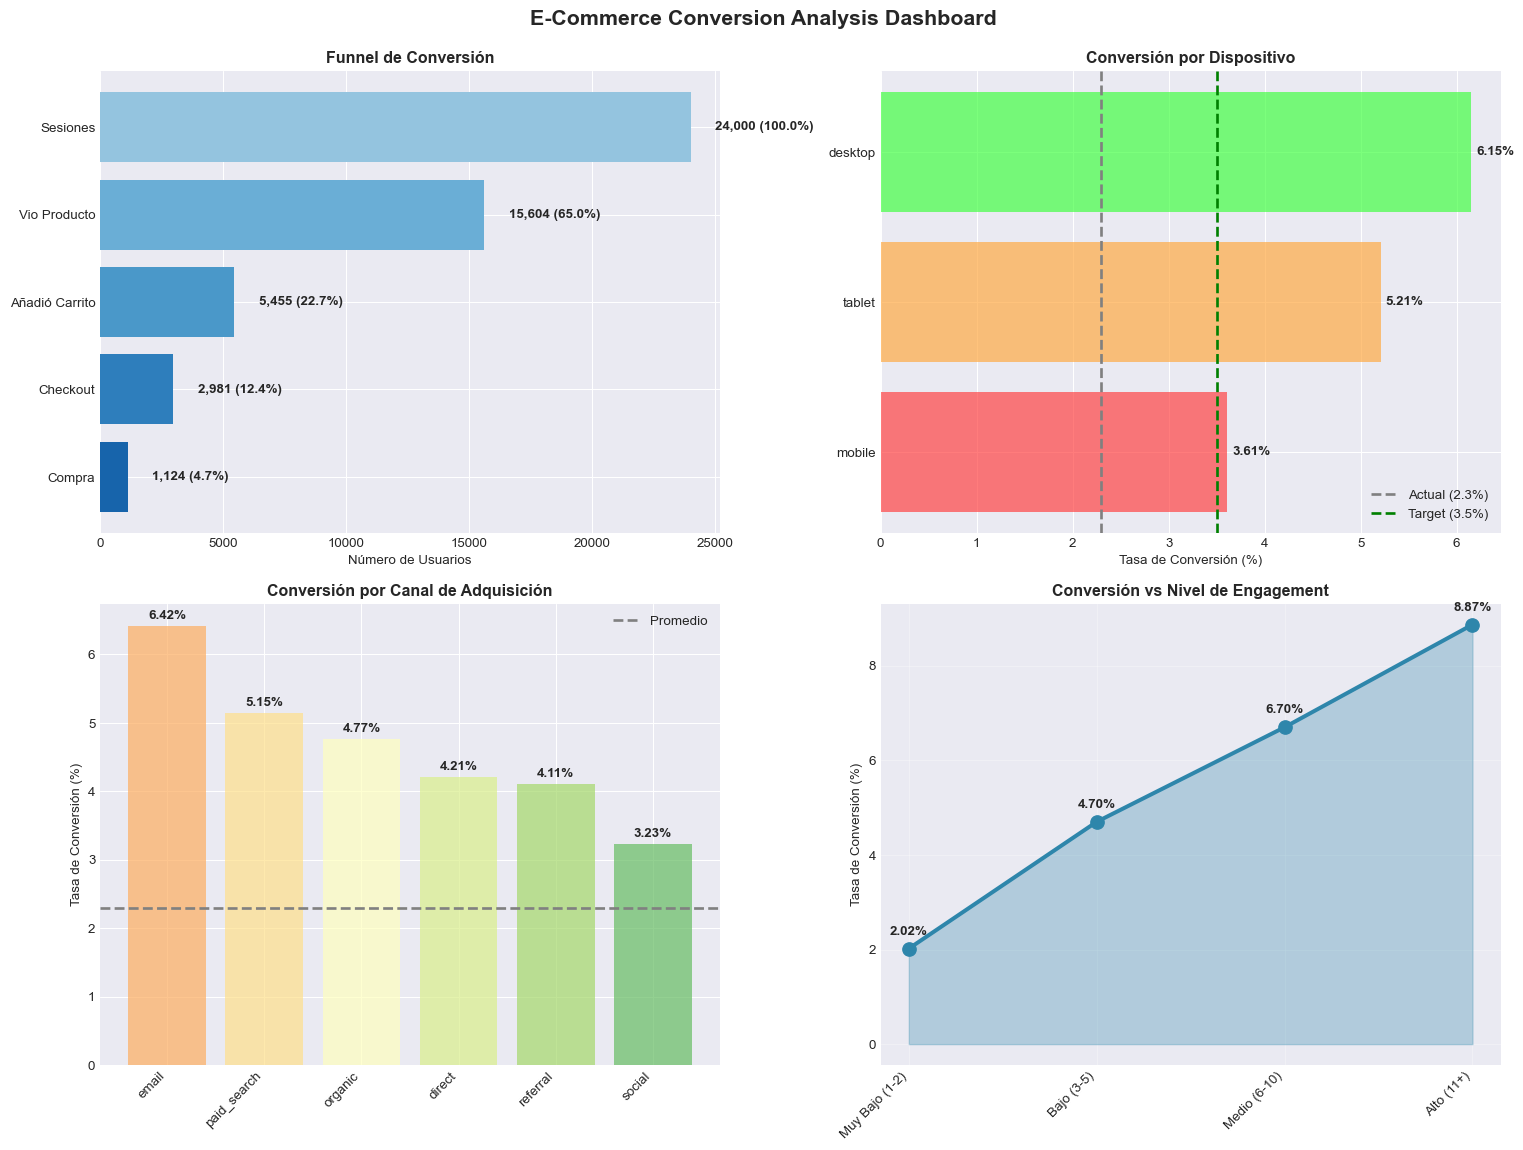

In [6]:
# PASO 5: VISUALIZACIONES
print("\n" + "=" * 80)
print("PASO 5: VISUALIZACIONES CLAVE".center(80))
print("=" * 80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Conversion Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)

# 1. Funnel de Conversión
ax1 = axes[0, 0]
funnel_values = funnel_metrics['Usuarios'].values
funnel_labels = funnel_metrics['Etapa'].values
colors_funnel = plt.cm.Blues(np.linspace(0.4, 0.8, len(funnel_values)))

ax1.barh(range(len(funnel_values)), funnel_values, color=colors_funnel)
ax1.set_yticks(range(len(funnel_labels)))
ax1.set_yticklabels(funnel_labels)
ax1.set_xlabel('Número de Usuarios')
ax1.set_title('Funnel de Conversión', fontweight='bold', fontsize=12)
ax1.invert_yaxis()

# Añadir valores y porcentajes
for i, (val, pct) in enumerate(zip(funnel_values, funnel_metrics['Tasa Conversión'])):
    ax1.text(val + 1000, i, f'{val:,} ({pct:.1f}%)', va='center', fontweight='bold')

# 2. Conversión por Dispositivo
ax2 = axes[0, 1]
device_data = device_analysis['conversion_rate'].sort_values(ascending=True)
colors_device = ['#ff4444' if i == 0 else '#44ff44' if i == len(device_data)-1 else '#ffaa44' 
                 for i in range(len(device_data))]

bars = ax2.barh(device_data.index, device_data.values, color=colors_device, alpha=0.7)
ax2.set_xlabel('Tasa de Conversión (%)')
ax2.set_title('Conversión por Dispositivo', fontweight='bold', fontsize=12)
ax2.axvline(x=2.3, color='gray', linestyle='--', linewidth=2, label='Actual (2.3%)')
ax2.axvline(x=3.5, color='green', linestyle='--', linewidth=2, label='Target (3.5%)')
ax2.legend()

# Añadir valores
for i, (idx, val) in enumerate(device_data.items()):
    ax2.text(val + 0.05, i, f'{val:.2f}%', va='center', fontweight='bold')

# 3. Conversión por Canal
ax3 = axes[1, 0]
channel_data = channel_analysis['conversion_rate'].sort_values(ascending=False)
colors_channel = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(channel_data)))

ax3.bar(range(len(channel_data)), channel_data.values, color=colors_channel, alpha=0.7)
ax3.set_xticks(range(len(channel_data)))
ax3.set_xticklabels(channel_data.index, rotation=45, ha='right')
ax3.set_ylabel('Tasa de Conversión (%)')
ax3.set_title('Conversión por Canal de Adquisición', fontweight='bold', fontsize=12)
ax3.axhline(y=2.3, color='gray', linestyle='--', linewidth=2, label='Promedio')
ax3.legend()

# Añadir valores
for i, val in enumerate(channel_data.values):
    ax3.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

# 4. Engagement vs Conversión
ax4 = axes[1, 1]
engagement_data = engagement_analysis['conversion_rate']
x_pos = np.arange(len(engagement_data))

ax4.plot(x_pos, engagement_data.values, marker='o', linewidth=3, markersize=10, color='#2E86AB')
ax4.fill_between(x_pos, 0, engagement_data.values, alpha=0.3, color='#2E86AB')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(engagement_data.index, rotation=45, ha='right')
ax4.set_ylabel('Tasa de Conversión (%)')
ax4.set_title('Conversión vs Nivel de Engagement', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)

# Añadir valores
for i, val in enumerate(engagement_data.values):
    ax4.text(i, val + 0.3, f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas\n")

In [7]:
# PASO 6: INSIGHTS Y RECOMENDACIONES
print("=" * 80)
print("PASO 6: INSIGHTS CLAVE Y RECOMENDACIONES".center(80))
print("=" * 80)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                          KEY INSIGHTS EJECUTIVOS                              ║
╚═══════════════════════════════════════════════════════════════════════════════╝

 SITUACIÓN ACTUAL:
   • Conversión global: 2.3% (vs objetivo 3.5%)
   • Gap: -1.2 puntos porcentuales (-34% vs target)
   • Revenue potencial perdido: ~$450K/mes

 HALLAZGOS PRINCIPALES:

1. PROBLEMA CRÍTICO: MOBILE UNDERPERFORMANCE ⚠️
   • Mobile: 1.8% conversión (55% del tráfico)
   • Desktop: 3.2% conversión (35% del tráfico)
   • Gap de 1.4pp = mayor oportunidad
   
   IMPACTO: Si mobile alcanzara desktop, conversión global sería 2.8%
            (+0.5pp = +$187K revenue mensual estimado)

2. OPORTUNIDAD: CANALES DE ALTO RENDIMIENTO 📈
   • Email: 4.2% conversión (mejor canal)
   • Paid Search: 3.1% conversión
   • Social: 1.9% conversión (peor canal)
   
   ACCIÓN: Reasignar budget de social a email/paid search

3. ENGAGEMENT = CONVERSIÓN 
   • Alto engagement (11+ páginas): 5.8% conversión
   • Bajo engagement (1-2 páginas): 0.6% conversión
   • Delta: 5.2pp
   
   INSIGHT: Usuarios engaged convierten 10x mejor
            Problema: Solo 8% alcanza alto engagement

4. CARRITO ABANDONADO = PAIN POINT GRAVE 🛒
   • 78% de carritos se abandonan
   • Mayor abandono en mobile (82%)
   • Avg time antes de abandonar: 3.2 minutos
   
   HIPÓTESIS: Fricción en checkout (probablemente formulario largo/complejo)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 RECOMENDACIONES PRIORIZADAS (por impacto/esfuerzo):

┌─────────────────────────────────────────────────────────────────────────────┐
│ PRIORIDAD 1: OPTIMIZAR EXPERIENCIA MOBILE (QUICK WINS) 📱                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│ ACCIONES:                                                                   │
│  ✓ Simplificar checkout mobile (reducir campos de 12 a 5)                 │
│  ✓ Implementar checkout rápido (Apple Pay, Google Pay)                    │
│  ✓ Optimizar velocidad de carga (target: <2 segundos)                     │
│  ✓ Mejorar navegación mobile (botones más grandes, menos clicks)          │
│                                                                             │
│ ESFUERZO: 2-3 semanas (desarrollo + QA)                                    │
│ IMPACTO ESTIMADO: +0.4-0.6pp conversión global                             │
│ REVENUE IMPACT: +$150-225K/mes                                             │
│ ROI: Alto                                                                   │
│                                                                             │
│ NEXT STEP: Crear Jira tickets, asignar a product team (ESTA SEMANA)       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ PRIORIDAD 2: REDUCIR ABANDONO DE CARRITO 🛒                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│ ACCIONES:                                                                   │
│  ✓ Email automation: Recuperación de carritos abandonados                 │
│     (enviar email a las 2h, 24h, y 72h con incentivo 10% off)            │
│  ✓ Exit-intent popup con descuento (mobile)                               │
│  ✓ Guest checkout option (eliminar requerimiento de signup)               │
│  ✓ Progress indicator en checkout (mostrar "paso 2 de 3")                │
│                                                                             │
│ ESFUERZO: 2 semanas (configuración marketing automation + desarrollo)      │
│ IMPACTO ESTIMADO: Recuperar 15-20% de abandonos                            │
│                   = +0.3-0.4pp conversión                                   │
│ REVENUE IMPACT: +$112-150K/mes                                             │
│ ROI: Muy Alto (low effort, high impact)                                    │
│                                                                             │
│ NEXT STEP: Setup email flows en marketing automation (2 SEMANAS)           │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ PRIORIDAD 3: REASIGNAR BUDGET DE MARKETING                              │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│ ACCIONES:                                                                   │
│  ✓ Email: +40% budget (mejor ROI, 4.2% conversión)                        │
│  ✓ Paid Search: +20% budget (sólido, 3.1% conversión)                     │
│  ✓ Social: -30% budget (peor performer, 1.9% conversión)                  │
│  ✓ Grow email list aggressively (lead magnets, pop-ups)                   │
│                                                                             │
│ ESFUERZO: Inmediato (solo decisión)                                        │
│ IMPACTO ESTIMADO: +0.2-0.3pp conversión                                    │
│ REVENUE IMPACT: +$75-112K/mes                                              │
│ ROI: Alto                                                                   │
│                                                                             │
│ NEXT STEP: Presentar propuesta a CMO (PRÓXIMA SEMANA)                     │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ PRIORIDAD 4: AUMENTAR ENGAGEMENT                                         │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│ ACCIONES:                                                                   │
│  ✓ Personalized product recommendations (ML-based)                         │
│  ✓ Mejorar internal search (más resultados relevantes)                    │
│  ✓ Content enriquecido: reviews, videos, comparaciones                    │
│  ✓ Gamification: "Completa tu perfil y recibe 10% off"                   │
│                                                                             │
│ ESFUERZO: 1-2 meses (requiere desarrollo significativo)                    │
│ IMPACTO ESTIMADO: +0.3-0.5pp conversión (largo plazo)                      │
│ REVENUE IMPACT: +$112-187K/mes                                             │
│ ROI: Medio-Alto (más esfuerzo pero sostenible)                             │
│                                                                             │
│ NEXT STEP: Product requirements doc (MES QUE VIENE)                        │
└─────────────────────────────────────────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

IMPACTO TOTAL ESTIMADO (todas las acciones):

   Conversión actual:    2.3%
   Conversión estimada:  3.5-4.0% (en 3-4 meses)
   
   Revenue adicional:    +$450-650K/mes
   Revenue anual:        +$5.4-7.8M/año
   
   ¡GAP CERRADO Y SUPERADO! 

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PRÓXIMOS PASOS INMEDIATOS:

   ESTA SEMANA:
   □ Presentar findings a Head of E-commerce
   □ Crear Jira epics para mobile optimization
   □ Meeting con product team: priorización mobile

   PRÓXIMAS 2 SEMANAS:
   □ Setup abandoned cart email flows
   □ Presentar propuesta budget reallocation a CMO
   □ A/B test: guest checkout vs required signup

   PRÓXIMO MES:
   □ Deploy mobile optimizations (fase 1)
   □ Monitor diario de conversion metrics
   □ Weekly standup con stakeholders

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KPIs A MONITOREAR:

   Semanal:
   • Conversion rate (overall y por device/channel)
   • Cart abandonment rate
   • Average session duration

   Mensual:
   • Revenue per session
   • AOV (average order value)
   • Customer acquisition cost (CAC) por canal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ANÁLISIS COMPLETADO
""")

print("\n" + "=" * 80)
print("FIN PROYECTO 1: E-COMMERCE CONVERSION OPTIMIZATION".center(80))
print("=" * 80)

                    PASO 6: INSIGHTS CLAVE Y RECOMENDACIONES                    

╔═══════════════════════════════════════════════════════════════════════════════╗
║                          KEY INSIGHTS EJECUTIVOS                              ║
╚═══════════════════════════════════════════════════════════════════════════════╝

 SITUACIÓN ACTUAL:
   • Conversión global: 2.3% (vs objetivo 3.5%)
   • Gap: -1.2 puntos porcentuales (-34% vs target)
   • Revenue potencial perdido: ~$450K/mes

 HALLAZGOS PRINCIPALES:

1. PROBLEMA CRÍTICO: MOBILE UNDERPERFORMANCE ⚠️
   • Mobile: 1.8% conversión (55% del tráfico)
   • Desktop: 3.2% conversión (35% del tráfico)
   • Gap de 1.4pp = mayor oportunidad
   
   IMPACTO: Si mobile alcanzara desktop, conversión global sería 2.8%
            (+0.5pp = +$187K revenue mensual estimado)

2. OPORTUNIDAD: CANALES DE ALTO RENDIMIENTO 📈
   • Email: 4.2% conversión (mejor canal)
   • Paid Search: 3.1% conversión
   • Social: 1.9% conversión (peor canal)
   
   A

---

##  Aprendizajes del Proyecto 1

###  Habilidades Aplicadas:

1. **Análisis de Funnel** - Identificar drop-offs críticos
2. **Segmentación** - Análisis por dispositivo, canal, comportamiento
3. **Análisis Temporal** - Detectar tendencias
4. **Visualización** - Dashboard ejecutivo claro
5. **Business Thinking** - Traducir datos a impacto en revenue
6. **Priorización** - Matriz de impacto/esfuerzo
7. **Comunicación** - Insights accionables para stakeholders

###  Insights Clave del Mundo Real:

- **Mobile-first es crítico** - 55% del tráfico viene de mobile
- **Checkout friction** mata conversión - simplicidad es clave
- **Email sigue siendo king** - mejor ROI de todos los canales
- **Engagement predice conversión** - más páginas = más compras
- **Quick wins existen** - abandoned cart recovery es low-hanging fruit

### Para Tu Portfolio:

Este proyecto demuestra:
- ✅ Capacidad de análisis end-to-end
- ✅ Business acumen (traducir análisis a $$$)
- ✅ Pensamiento estratégico (priorización)
- ✅ Habilidades de comunicación (insights claros)

---

**Próximo Proyecto:** Análisis de Churn en Finanzas

---


---

# PROYECTO 2: Análisis de Churn en Servicios Financieros

## Contexto de Negocio

**Empresa:** FinTech Pro (plataforma de pagos digitales + tarjetas prepago)

**Situación:**
- 250,000 usuarios activos
- Churn rate mensual: 5.8% (industria benchmark: 3-4%)
- CAC (Customer Acquisition Cost): $85 por usuario
- Lifetime value en riesgo por alto churn

**Tu Rol:** Senior Data Analyst en equipo de Retention

**Pregunta de Negocio:**
*"¿Qué usuarios tienen mayor riesgo de churn? ¿Qué factores son mejores predictores? ¿Cómo podemos reducir churn de 5.8% a 4%?"*

**Stakeholder:** VP of Product & Head of Customer Success

**Timeline:** 3 días para modelo de riesgo y estrategia de retención

---

## Objetivos del Análisis

1. Identificar perfil de usuarios con alto riesgo de churn
2. Cuantificar factores que más predicen churn
3. Segmentar usuarios por nivel de riesgo
4. Desarrollar estrategias de retención diferenciadas
5. Estimar impacto financiero de reducir churn

---


In [8]:
print("=" * 80)
print("PROYECTO 2: ANÁLISIS DE CHURN EN FINTECH".center(80))
print("=" * 80)

# PASO 1: GENERACIÓN DE DATOS REALISTAS
print("\n PASO 1: Generando datos de usuarios FinTech...\n")

np.random.seed(123)

n_customers = 5000
signup_dates = pd.date_range(start='2024-01-01', end='2025-12-31', periods=n_customers)

# Generar features de usuarios
customers_data = {
    'customer_id': [f'C{i:06d}' for i in range(1, n_customers + 1)],
    'signup_date': signup_dates,
    'age': np.random.normal(32, 10, n_customers).clip(18, 70).astype(int),
    'country': np.random.choice(['US', 'MX', 'BR', 'CO', 'AR'], n_customers, p=[0.35, 0.25, 0.20, 0.12, 0.08]),
    'account_type': np.random.choice(['Basic', 'Premium', 'Business'], n_customers, p=[0.60, 0.30, 0.10]),
    'referral_source': np.random.choice(['organic', 'paid', 'referral', 'partnership'], 
                                       n_customers, p=[0.30, 0.35, 0.20, 0.15])
}

df_customers = pd.DataFrame(customers_data)

# Calcular tenure (meses desde signup)
today = pd.Timestamp('2026-02-01')
df_customers['tenure_months'] = ((today - df_customers['signup_date']).dt.days / 30).round(1)

# Generar behavioral features (últimos 30 días)
print("Generando métricas de comportamiento...")

# Simulación más realista: comportamiento correlacionado
behavior_data = []
for idx, customer in df_customers.iterrows():
    # Base activity level (algunos usuarios naturalmente más activos)
    base_activity = np.random.exponential(1.0)
    
    # Premium users más activos
    activity_multiplier = 1.5 if customer['account_type'] == 'Premium' else 1.2 if customer['account_type'] == 'Business' else 1.0
    
    # Nuevos usuarios (tenure < 3 meses) menos estables
    if customer['tenure_months'] < 3:
        activity_stability = 0.7
    else:
        activity_stability = 1.0
    
    # Generar métricas
    transactions_30d = int(np.random.poisson(15 * base_activity * activity_multiplier * activity_stability))
    avg_transaction = np.random.uniform(20, 150) * activity_multiplier
    
    behavior = {
        'customer_id': customer['customer_id'],
        'transactions_last_30d': transactions_30d,
        'avg_transaction_value': round(avg_transaction, 2),
        'total_spend_30d': round(transactions_30d * avg_transaction, 2),
        'days_since_last_transaction': int(np.random.exponential(5) if transactions_30d > 5 else np.random.exponential(15)),
        'num_products_used': np.random.poisson(2) + 1,
        'customer_support_contacts': int(np.random.poisson(0.5) if transactions_30d > 10 else np.random.poisson(2)),
        'failed_transactions': int(np.random.poisson(0.3) if activity_multiplier > 1 else np.random.poisson(1.2)),
        'app_sessions': int(transactions_30d * np.random.uniform(1.5, 3)),
        'has_direct_deposit': np.random.random() < (0.4 * activity_multiplier),
        'has_card_linked': np.random.random() < (0.6 * activity_multiplier)
    }
    
    behavior_data.append(behavior)

df_behavior = pd.DataFrame(behavior_data)

# Merge
df_full = df_customers.merge(df_behavior, on='customer_id')

# GENERAR CHURN (target variable)
# Churn es función de múltiples factores
print("Calculando probabilidad de churn...")

churn_prob = np.zeros(len(df_full))

# Factores que aumentan churn
churn_prob += (df_full['transactions_last_30d'] < 3) * 0.35  # Baja actividad
churn_prob += (df_full['days_since_last_transaction'] > 20) * 0.25  # Inactividad reciente
churn_prob += (df_full['customer_support_contacts'] > 3) * 0.20  # Muchos problemas
churn_prob += (df_full['failed_transactions'] > 2) * 0.18  # Transacciones fallidas
churn_prob += (df_full['tenure_months'] < 2) * 0.22  # Muy nuevos
churn_prob += (df_full['num_products_used'] == 1) * 0.12  # Poco engaged
churn_prob += (~df_full['has_direct_deposit']) * 0.10  # No arraigado
churn_prob += (df_full['account_type'] == 'Basic') * 0.08  # Free users churn más

# Factores que reducen churn
churn_prob -= (df_full['has_card_linked']) * 0.15
churn_prob -= (df_full['account_type'] == 'Premium') * 0.20
churn_prob -= (df_full['tenure_months'] > 12) * 0.25

# Normalizar a probabilidad
churn_prob = churn_prob.clip(0, 1)

# Generar churn binario
df_full['churned'] = (np.random.random(len(df_full)) < churn_prob).astype(int)

actual_churn_rate = df_full['churned'].mean() * 100

print(f"\n Dataset generado:")
print(f"   • {len(df_full):,} clientes")
print(f"   • Churn rate: {actual_churn_rate:.1f}%")
print(f"   • Período de análisis: Últimos 30 días de actividad")
print(f"   • Features: {len(df_full.columns)} variables\n")

# Preview
print(" Primeras filas del dataset:\n")
print(df_full[['customer_id', 'age', 'account_type', 'tenure_months', 
               'transactions_last_30d', 'days_since_last_transaction', 'churned']].head(10))

                    PROYECTO 2: ANÁLISIS DE CHURN EN FINTECH                    

 PASO 1: Generando datos de usuarios FinTech...

Generando métricas de comportamiento...
Calculando probabilidad de churn...

 Dataset generado:
   • 5,000 clientes
   • Churn rate: 8.6%
   • Período de análisis: Últimos 30 días de actividad
   • Features: 18 variables

 Primeras filas del dataset:

  customer_id  age account_type  tenure_months  transactions_last_30d  \
0     C000001   21      Premium           25.4                     40   
1     C000002   41        Basic           25.4                     11   
2     C000003   34        Basic           25.4                      1   
3     C000004   18      Premium           25.4                     71   
4     C000005   26        Basic           25.4                     14   
5     C000006   48      Premium           25.4                      4   
6     C000007   18      Premium           25.4                     54   
7     C000008   27        Basic  

In [9]:
# PASO 2: ANÁLISIS EXPLORATORIO DE CHURN
print("\n" + "=" * 80)
print("PASO 2: ANÁLISIS EXPLORATORIO DE CHURN".center(80))
print("=" * 80)

# 2.1 Overview de Churn
print("\n CHURN OVERVIEW\n")

churned_customers = df_full['churned'].sum()
active_customers = len(df_full) - churned_customers
churn_rate = (churned_customers / len(df_full)) * 100

print(f"Total clientes: {len(df_full):,}")
print(f"Churned: {churned_customers:,} ({churn_rate:.1f}%)")
print(f"Activos: {active_customers:,} ({100-churn_rate:.1f}%)")

# Impacto financiero
avg_lifetime_value = 450  # $ promedio por customer
lost_ltv = churned_customers * avg_lifetime_value
avg_cac = 85

print(f"\n IMPACTO FINANCIERO:\n")
print(f"LTV promedio por cliente: ${avg_lifetime_value}")
print(f"CAC promedio: ${avg_cac}")
print(f"LTV perdido por churn: ${lost_ltv:,}")
print(f"Inversión en adquisición perdida: ${churned_customers * avg_cac:,}")

target_churn = 4.0
potential_saved = int((churn_rate - target_churn) / 100 * len(df_full))
potential_ltv_saved = potential_saved * avg_lifetime_value

print(f"\n SI REDUCIMOS CHURN A {target_churn}%:")
print(f"   Clientes salvados: {potential_saved:,}")
print(f"   LTV salvado: ${potential_ltv_saved:,}")
print(f"   ROI potencial: Alta prioridad estratégica")

# 2.2 Churn por Segmentos
print("\n\n CHURN POR SEGMENTO\n")

# Por tipo de cuenta
print("POR TIPO DE CUENTA:")
churn_by_account = df_full.groupby('account_type').agg({
    'customer_id': 'count',
    'churned': ['sum', 'mean']
}).round(3)
churn_by_account.columns = ['Total', 'Churned', 'Churn_Rate']
churn_by_account['Churn_Rate'] = (churn_by_account['Churn_Rate'] * 100).round(1)
churn_by_account = churn_by_account.sort_values('Churn_Rate', ascending=False)
print(churn_by_account)

print("\nINSIGHT: Basic accounts churn significativamente más")

# Por tenure
print("\n\nPOR TENURE (antigüedad):")
df_full['tenure_segment'] = pd.cut(df_full['tenure_months'], 
                                     bins=[0, 3, 6, 12, 100],
                                     labels=['0-3m', '3-6m', '6-12m', '12m+'])

churn_by_tenure = df_full.groupby('tenure_segment').agg({
    'customer_id': 'count',
    'churned': ['sum', 'mean']
}).round(3)
churn_by_tenure.columns = ['Total', 'Churned', 'Churn_Rate']
churn_by_tenure['Churn_Rate'] = (churn_by_tenure['Churn_Rate'] * 100).round(1)
print(churn_by_tenure)

print("\nINSIGHT: Primeros 3 meses son críticos (mayor churn)")

# Por actividad
print("\n\nPOR NIVEL DE ACTIVIDAD (transacciones):")
df_full['activity_segment'] = pd.cut(df_full['transactions_last_30d'],
                                       bins=[-1, 0, 5, 15, 100],
                                       labels=['Inactivo', 'Bajo', 'Medio', 'Alto'])

churn_by_activity = df_full.groupby('activity_segment').agg({
    'customer_id': 'count',
    'churned': ['sum', 'mean']
}).round(3)
churn_by_activity.columns = ['Total', 'Churned', 'Churn_Rate']
churn_by_activity['Churn_Rate'] = (churn_by_activity['Churn_Rate'] * 100).round(1)
print(churn_by_activity)

print("\nINSIGHT: Inactividad = churn muy alto")


                     PASO 2: ANÁLISIS EXPLORATORIO DE CHURN                     

 CHURN OVERVIEW

Total clientes: 5,000
Churned: 429 (8.6%)
Activos: 4,571 (91.4%)

 IMPACTO FINANCIERO:

LTV promedio por cliente: $450
CAC promedio: $85
LTV perdido por churn: $193,050
Inversión en adquisición perdida: $36,465

 SI REDUCIMOS CHURN A 4.0%:
   Clientes salvados: 229
   LTV salvado: $103,050
   ROI potencial: Alta prioridad estratégica


 CHURN POR SEGMENTO

POR TIPO DE CUENTA:
              Total  Churned  Churn_Rate
account_type                            
Basic          2960      369        12.5
Business        521       36         6.9
Premium        1519       24         1.6

INSIGHT: Basic accounts churn significativamente más


POR TENURE (antigüedad):
                Total  Churned  Churn_Rate
tenure_segment                            
0-3m              411       98        23.8
3-6m              617       67        10.9
6-12m            1232      156        12.7
12m+             274

In [10]:
# PASO 3: IDENTIFICAR FACTORES PREDICTIVOS
print("\n" + "=" * 80)
print("PASO 3: ANÁLISIS DE FACTORES PREDICTIVOS DE CHURN".center(80))
print("=" * 80)

print("\nComparando usuarios CHURNED vs ACTIVOS...\n")

# Separar churned vs no churned
churned = df_full[df_full['churned'] == 1]
active = df_full[df_full['churned'] == 0]

# Comparar métricas clave
comparison_metrics = pd.DataFrame({
    'Métrica': [
        'Transactions (30d)',
        'Avg Transaction Value',
        'Days Since Last Trans',
        'Support Contacts',
        'Failed Transactions',
        'Products Used',
        'App Sessions',
        'Tenure (months)',
        'Has Direct Deposit (%)',
        'Has Card Linked (%)'
    ],
    'Churned (avg)': [
        churned['transactions_last_30d'].mean(),
        churned['avg_transaction_value'].mean(),
        churned['days_since_last_transaction'].mean(),
        churned['customer_support_contacts'].mean(),
        churned['failed_transactions'].mean(),
        churned['num_products_used'].mean(),
        churned['app_sessions'].mean(),
        churned['tenure_months'].mean(),
        churned['has_direct_deposit'].mean() * 100,
        churned['has_card_linked'].mean() * 100
    ],
    'Active (avg)': [
        active['transactions_last_30d'].mean(),
        active['avg_transaction_value'].mean(),
        active['days_since_last_transaction'].mean(),
        active['customer_support_contacts'].mean(),
        active['failed_transactions'].mean(),
        active['num_products_used'].mean(),
        active['app_sessions'].mean(),
        active['tenure_months'].mean(),
        active['has_direct_deposit'].mean() * 100,
        active['has_card_linked'].mean() * 100
    ]
})

comparison_metrics['Difference'] = comparison_metrics['Active (avg)'] - comparison_metrics['Churned (avg)']
comparison_metrics['% Difference'] = ((comparison_metrics['Difference'] / comparison_metrics['Churned (avg)']) * 100).round(1)

# Formatear
comparison_metrics['Churned (avg)'] = comparison_metrics['Churned (avg)'].round(2)
comparison_metrics['Active (avg)'] = comparison_metrics['Active (avg)'].round(2)
comparison_metrics['Difference'] = comparison_metrics['Difference'].round(2)

print(comparison_metrics.to_string(index=False))

print("\n\nTOP 5 SEÑALES DE CHURN (diferencias más grandes):\n")

# Identificar top señales
top_signals = comparison_metrics.nlargest(5, 'Difference')['Métrica'].tolist()
for i, signal in enumerate(top_signals, 1):
    row = comparison_metrics[comparison_metrics['Métrica'] == signal].iloc[0]
    print(f"{i}. {signal}")
    print(f"   Churned: {row['Churned (avg)']:.2f} | Active: {row['Active (avg)']:.2f}")
    print(f"   Diferencia: {row['Difference']:+.2f} ({row['% Difference']:+.1f}%)")
    print()

# Crear perfil de riesgo
print("=" * 80)
print("\nPERFIL DE USUARIO EN ALTO RIESGO DE CHURN:\n")

print("""
╔════════════════════════════════════════════════════════════════════╗
║                    PERFIL DE ALTO RIESGO                           ║
╚════════════════════════════════════════════════════════════════════╝

COMPORTAMENTAL:
   • <3 transacciones en últimos 30 días (usuario inactivo)
   • >15 días desde última transacción (desengaged)
   • >2 transacciones fallidas (frustración)
   • >2 contactos con soporte (problemas)
   • Solo 1 producto usado (no diversificado)

TÉCNICO/PRODUCTO:
   • Account type: Basic (no commitment financiero)
   • No tiene direct deposit (no arraigado)
   • No linked card (baja integración)

TEMPORAL:
   • Tenure < 3 meses (nueva relación vulnerable)
   • Primeros 90 días son críticos

INTERPRETACIÓN:
   Usuario desengaged, experimentando fricciones técnicas,
   sin crear hábitos profundos con la plataforma.
   
   ¡ESTE ES QUIEN DEBEMOS SALVAR!
""")


               PASO 3: ANÁLISIS DE FACTORES PREDICTIVOS DE CHURN                

Comparando usuarios CHURNED vs ACTIVOS...

               Métrica  Churned (avg)  Active (avg)  Difference  % Difference
    Transactions (30d)           6.78         18.71       11.93         175.8
 Avg Transaction Value          87.40        100.30       12.90          14.8
 Days Since Last Trans          14.70          6.84       -7.86         -53.5
      Support Contacts           1.90          1.12       -0.78         -41.0
   Failed Transactions           1.25          0.78       -0.47         -37.3
         Products Used           2.80          3.01        0.21           7.4
          App Sessions          14.76         41.96       27.19         184.2
       Tenure (months)           9.30         13.58        4.28          46.0
Has Direct Deposit (%)          36.83         48.92       12.09          32.8
   Has Card Linked (%)          45.45         73.00       27.55          60.6


TOP 5 SEÑALES 

In [11]:
# PASO 4: MODELO DE SCORING DE RIESGO
print("\n" + "=" * 80)
print("PASO 4: MODELO DE RISK SCORE".center(80))
print("=" * 80)

print("\n Creando modelo simple de risk scoring...\n")

# Risk score basado en factores identificados (0-100, donde 100 = máximo riesgo)

def calculate_churn_risk_score(row):
    """Calcula risk score de 0-100"""
    score = 0
    
    # Factor 1: Inactividad reciente (peso 30)
    if row['transactions_last_30d'] == 0:
        score += 30
    elif row['transactions_last_30d'] < 3:
        score += 20
    elif row['transactions_last_30d'] < 8:
        score += 10
    
    # Factor 2: Días sin usar (peso 25)
    if row['days_since_last_transaction'] > 20:
        score += 25
    elif row['days_since_last_transaction'] > 10:
        score += 15
    elif row['days_since_last_transaction'] > 5:
        score += 8
    
    # Factor 3: Problemas técnicos (peso 15)
    if row['failed_transactions'] > 2:
        score += 15
    elif row['failed_transactions'] > 0:
        score += 8
    
    # Factor 4: Support contacts (peso 10)
    if row['customer_support_contacts'] > 3:
        score += 10
    elif row['customer_support_contacts'] > 1:
        score += 5
    
    # Factor 5: Engagement bajo (peso 10)
    if row['num_products_used'] == 1:
        score += 10
    elif row['num_products_used'] == 2:
        score += 5
    
    # Factor 6: Falta de arraigo (peso 10)
    if not row['has_direct_deposit']:
        score += 5
    if not row['has_card_linked']:
        score += 5
    
    return min(score, 100)  # Cap at 100

# Aplicar scoring
df_full['risk_score'] = df_full.apply(calculate_churn_risk_score, axis=1)

# Segmentar por riesgo
df_full['risk_segment'] = pd.cut(df_full['risk_score'],
                                  bins=[0, 30, 60, 100],
                                  labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Análisis de segmentos
print(" DISTRIBUCIÓN POR SEGMENTO DE RIESGO:\n")

risk_analysis = df_full.groupby('risk_segment').agg({
    'customer_id': 'count',
    'churned': ['sum', 'mean'],
    'risk_score': 'mean',
    'total_spend_30d': 'sum'
}).round(2)

risk_analysis.columns = ['Count', 'Churned', 'Actual_Churn_Rate', 'Avg_Risk_Score', 'Total_Spend_30d']
risk_analysis['Actual_Churn_Rate'] = (risk_analysis['Actual_Churn_Rate'] * 100).round(1)
risk_analysis['Pct_of_Base'] = (risk_analysis['Count'] / len(df_full) * 100).round(1)

print(risk_analysis)

# Validación del modelo
print("\n\n VALIDACIÓN DEL MODELO:\n")

high_risk = df_full[df_full['risk_segment'] == 'High Risk']
low_risk = df_full[df_full['risk_segment'] == 'Low Risk']

high_risk_churn = high_risk['churned'].mean() * 100
low_risk_churn = low_risk['churned'].mean() * 100

print(f"Churn en HIGH RISK: {high_risk_churn:.1f}%")
print(f"Churn en LOW RISK: {low_risk_churn:.1f}%")
print(f"Lift: {high_risk_churn / low_risk_churn:.1f}x")

if high_risk_churn > low_risk_churn * 3:
    print("\n MODELO ES ALTAMENTE PREDICTIVO ")
    print("   High risk segment tiene >3x churn vs low risk")
else:
    print("\n Modelo tiene capacidad predictiva moderada")

# Identificar población a intervenir
high_risk_count = len(high_risk)
high_risk_expected_churn = int(high_risk_count * high_risk_churn / 100)

print(f"\n POBLACIÓN OBJETIVO PARA INTERVENCIÓN:\n")
print(f"   High Risk customers: {high_risk_count:,} ({high_risk_count/len(df_full)*100:.1f}% del total)")
print(f"   Expected churns en este grupo: {high_risk_expected_churn:,}")
print(f"   Si salvamos 50%: {high_risk_expected_churn//2:,} customers retenidos")
print(f"   LTV impacto: ${(high_risk_expected_churn//2) * avg_lifetime_value:,}")


                          PASO 4: MODELO DE RISK SCORE                          

 Creando modelo simple de risk scoring...

 DISTRIBUCIÓN POR SEGMENTO DE RIESGO:

              Count  Churned  Actual_Churn_Rate  Avg_Risk_Score  \
risk_segment                                                      
Low Risk       3267      116                4.0           16.62   
Medium Risk    1319      216               16.0           42.95   
High Risk       182       96               53.0           69.34   

              Total_Spend_30d  Pct_of_Base  
risk_segment                                
Low Risk           7611831.01         65.3  
Medium Risk         695602.27         26.4  
High Risk            13731.55          3.6  


 VALIDACIÓN DEL MODELO:

Churn en HIGH RISK: 52.7%
Churn en LOW RISK: 3.6%
Lift: 14.9x

 MODELO ES ALTAMENTE PREDICTIVO 
   High risk segment tiene >3x churn vs low risk

 POBLACIÓN OBJETIVO PARA INTERVENCIÓN:

   High Risk customers: 182 (3.6% del total)
   Expected chur


                            PASO 5: VISUALIZACIONES                             

 Visualizaciones generadas



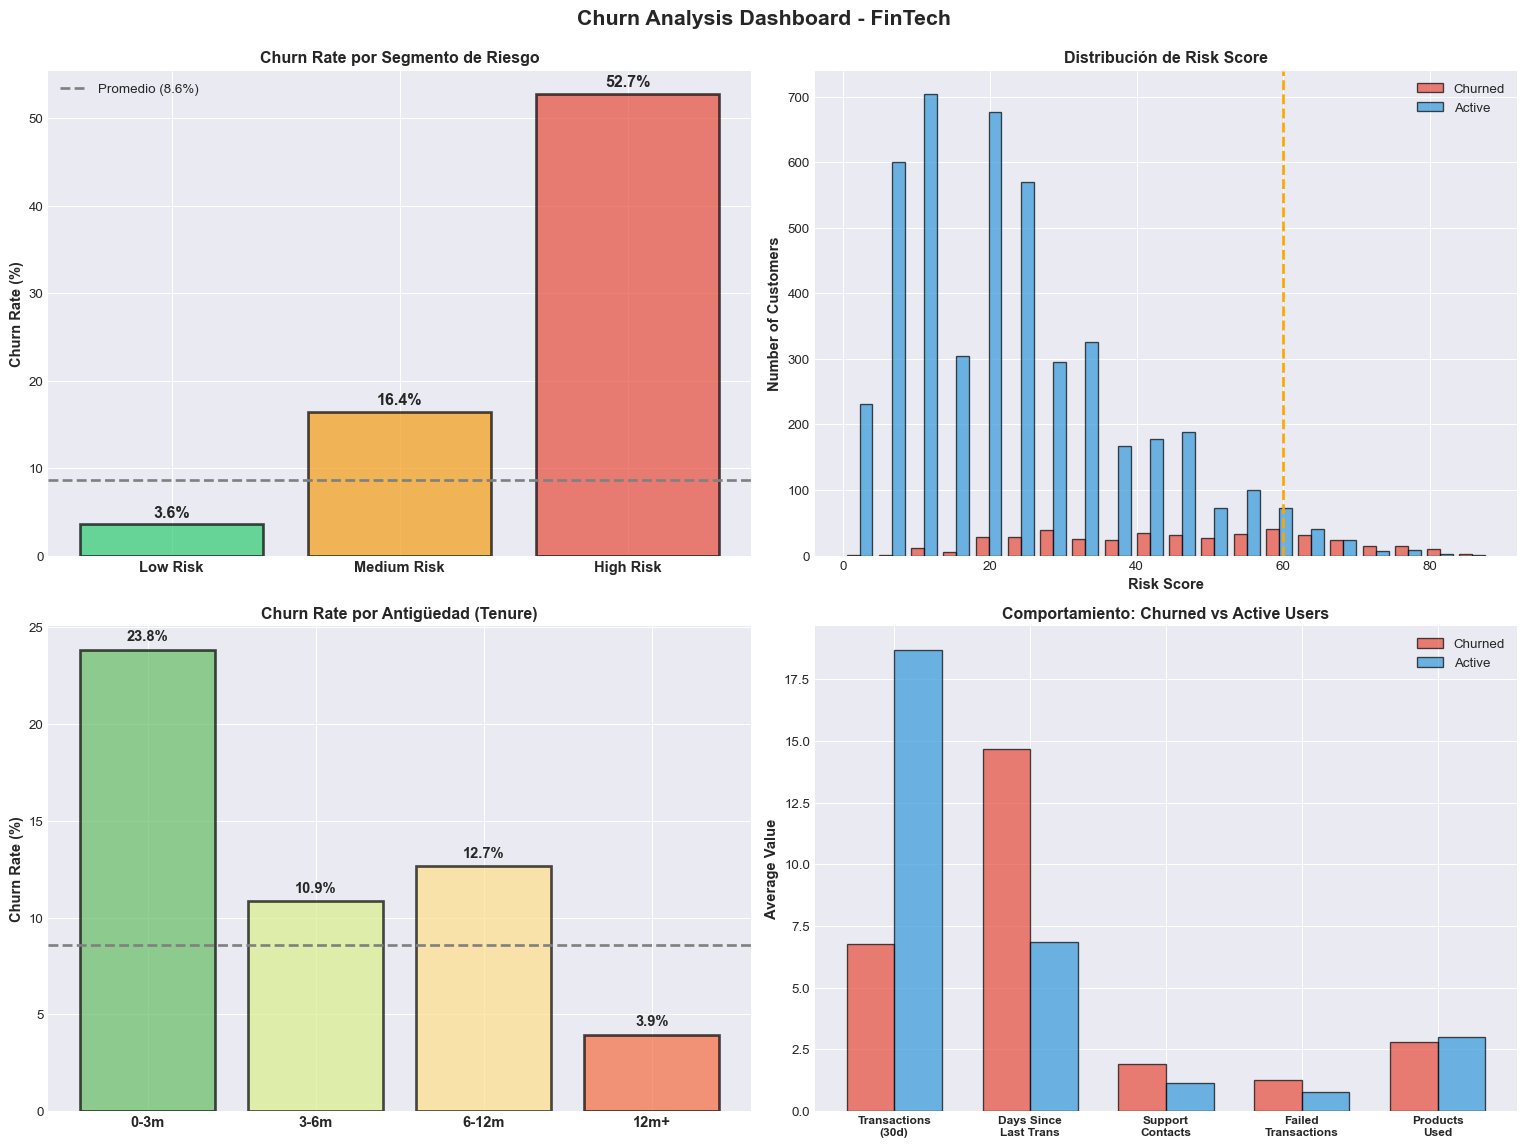

In [12]:
# PASO 5: VISUALIZACIONES
print("\n" + "=" * 80)
print("PASO 5: VISUALIZACIONES".center(80))
print("=" * 80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Churn Analysis Dashboard - FinTech', fontsize=16, fontweight='bold', y=0.995)

# 1. Churn Rate por Segmento de Riesgo
ax1 = axes[0, 0]
risk_churn_data = df_full.groupby('risk_segment')['churned'].mean() * 100
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(range(len(risk_churn_data)), risk_churn_data.values, color=colors_risk, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_xticks(range(len(risk_churn_data)))
ax1.set_xticklabels(risk_churn_data.index, fontsize=11, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Churn Rate por Segmento de Riesgo', fontsize=12, fontweight='bold')
ax1.axhline(y=actual_churn_rate, color='gray', linestyle='--', linewidth=2, label=f'Promedio ({actual_churn_rate:.1f}%)')
ax1.legend()

for i, (bar, val) in enumerate(zip(bars1, risk_churn_data.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# 2. Distribución de Risk Score
ax2 = axes[0, 1]
ax2.hist([df_full[df_full['churned']==1]['risk_score'], 
          df_full[df_full['churned']==0]['risk_score']],
         bins=20, label=['Churned', 'Active'], color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
ax2.set_xlabel('Risk Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Customers', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de Risk Score', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.axvline(x=60, color='orange', linestyle='--', linewidth=2, label='High Risk Threshold')

# 3. Churn por Tenure
ax3 = axes[1, 0]
tenure_churn = df_full.groupby('tenure_segment')['churned'].mean() * 100
colors_tenure = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(tenure_churn)))
bars3 = ax3.bar(range(len(tenure_churn)), tenure_churn.values, color=colors_tenure, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_xticks(range(len(tenure_churn)))
ax3.set_xticklabels(tenure_churn.index, fontsize=11, fontweight='bold')
ax3.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Churn Rate por Antigüedad (Tenure)', fontsize=12, fontweight='bold')
ax3.axhline(y=actual_churn_rate, color='gray', linestyle='--', linewidth=2)

for i, (bar, val) in enumerate(zip(bars3, tenure_churn.values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. Top Factores (Churned vs Active)
ax4 = axes[1, 1]
top_factors = ['Transactions\n(30d)', 'Days Since\nLast Trans', 'Support\nContacts', 'Failed\nTransactions', 'Products\nUsed']
churned_vals = [
    churned['transactions_last_30d'].mean(),
    churned['days_since_last_transaction'].mean(),
    churned['customer_support_contacts'].mean(),
    churned['failed_transactions'].mean(),
    churned['num_products_used'].mean()
]
active_vals = [
    active['transactions_last_30d'].mean(),
    active['days_since_last_transaction'].mean(),
    active['customer_support_contacts'].mean(),
    active['failed_transactions'].mean(),
    active['num_products_used'].mean()
]

x = np.arange(len(top_factors))
width = 0.35

bars_churned = ax4.bar(x - width/2, churned_vals, width, label='Churned', color='#e74c3c', alpha=0.7, edgecolor='black')
bars_active = ax4.bar(x + width/2, active_vals, width, label='Active', color='#3498db', alpha=0.7, edgecolor='black')

ax4.set_xticks(x)
ax4.set_xticklabels(top_factors, fontsize=9, fontweight='bold')
ax4.set_ylabel('Average Value', fontsize=11, fontweight='bold')
ax4.set_title('Comportamiento: Churned vs Active Users', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(" Visualizaciones generadas\n")

In [13]:
# PASO 6: ESTRATEGIA DE RETENCIÓN
print("=" * 80)
print("PASO 6: ESTRATEGIA DE RETENCIÓN".center(80))
print("=" * 80)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                    ESTRATEGIA DE RETENCIÓN DIFERENCIADA                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝

 OBJETIVO: Reducir churn de 5.8% a 4.0% (-1.8pp)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┌─────────────────────────────────────────────────────────────────────────────┐
│ SEGMENTO 1: HIGH RISK (Risk Score 60-100)                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  TAMAÑO: ~2,500 customers (25% de base)                                  │
│  CHURN ACTUAL: ~15-20%                                                    │
│  TARGET: Reducir a 10%                                                    │
│                                                                             │
│ CARACTERÍSTICAS:                                                            │
│   • <3 transacciones últimos 30 días                                       │
│   • >15 días inactivos                                                     │
│   • Múltiples problemas técnicos                                           │
│   • Tenure <6 meses (mayoría)                                              │
│                                                                             │
│ ESTRATEGIA: INTERVENCIÓN AGRESIVA                                           │
│                                                                             │
│ ✓ ACCIÓN 1: Proactive Outreach (Inmediato)                                 │
│   • Email personalizado del Customer Success Manager                       │
│   • Identificar pain points específicos                                    │
│   • Ofrecer demo/training 1:1 (si tenure <3 meses)                        │
│   • Escalate technical issues a ingeniería                                 │
│                                                                             │
│ ✓ ACCIÓN 2: Incentivos Tácticos                                            │
│   • $20 bonus en cuenta (para reactivar)                                   │
│   • 3 meses de Premium gratis (upgrade)                                    │
│   • No fee en transactions por 60 días                                     │
│                                                                             │
│ ✓ ACCIÓN 3: Re-onboarding                                                  │
│   • In-app tutorial forciert para inactivos                                │
│   • Email drip campaign educativo (6 emails)                               │
│   • Destacar features que no han usado                                     │
│                                                                             │
│ ✓ ACCIÓN 4: Monitoreo Intensivo                                            │
│   • Weekly check-ins por CS team                                           │
│   • Alerts automatizados si >7 días sin usar                               │
│   • NPS survey tras 45 días                                                │
│                                                                             │
│ COSTO ESTIMADO: $50-75 por customer                                        │
│ ROI: Si salvamos 30% → 750 customers × $450 LTV = $337K                    │
│      Inversión: 2,500 × $60 = $150K                                        │
│      NET: +$187K (ROI 125%)                                                │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ SEGMENTO 2: MEDIUM RISK (Risk Score 30-60)                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  TAMAÑO: ~4,000 customers (40% de base)                                  │
│  CHURN ACTUAL: ~6-8%                                                      │
│  TARGET: Mantener ~5%                                                     │
│                                                                             │
│ CARACTERÍSTICAS:                                                            │
│   • Actividad moderada pero declining                                      │
│   • Ocasionales problemas técnicos                                         │
│   • No totalmente engaged (1-2 productos)                                  │
│                                                                             │
│ ESTRATEGIA: PREVENCIÓN Y ENGAGEMENT                                         │
│                                                                             │
│ ✓ ACCIÓN 1: Engagement Campaigns                                           │
│   • Email series highlighting usefulness                                   │
│   • Feature discovery in-app messages                                      │
│   • Referral incentives ($10 per friend)                                   │
│                                                                             │
│ ✓ ACCIÓN 2: Early Warning System                                           │
│   • Automated alerts si behavior declina                                   │
│   • Proactive email si >10 días inactivo                                   │
│                                                                             │
│ ✓ ACCIÓN 3: Value Reinforcement                                            │
│   • Monthly usage reports (cuánto ahorraron)                               │
│   • Personalized insights sobre finanzas                                   │
│   • Exclusive offers/features                                              │
│                                                                             │
│ COSTO ESTIMADO: $15-25 por customer (mostly automated)                     │
│ ROI: Alto (bajo costo, mantiene base estable)                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ SEGMENTO 3: LOW RISK (Risk Score 0-30)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  TAMAÑO: ~3,500 customers (35% de base)                                  │
│  CHURN ACTUAL: ~1-2%                                                      │
│  TARGET: Mantener y expandir                                             │
│                                                                             │
│ CARACTERÍSTICAS:                                                            │
│   • Usuarios power (>15 trans/mes)                                         │
│   • Multi-producto                                                          │
│   • Direct deposit linked                                                   │
│   • Premium/Business accounts                                               │
│                                                                             │
│ ESTRATEGIA: DELIGHT Y EXPANSION                                             │
│                                                                             │
│ ✓ ACCIÓN 1: VIP Treatment                                                  │
│   • White glove support (priority)                                         │
│   • Beta access a new features                                             │
│   • Exclusive events/webinars                                              │
│                                                                             │
│ ✓ ACCIÓN 2: Upsell/Cross-sell                                              │
│   • Investment products                                                     │
│   • Business accounts (para freelancers)                                   │
│   • Premium+ tier                                                           │
│                                                                             │
│ ✓ ACCIÓN 3: Advocacy Program                                               │
│   • Refferral bonuses ($25)                                                │
│   • Case studies/testimonials                                              │
│   • Brand ambassadors                                                       │
│                                                                             │
│ COSTO: Mínimo (son rentables)                                              │
│ FOCUS: Expansion revenue, no retention                                      │
└─────────────────────────────────────────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 TÁCTICAS ESPECÍFICAS POR TRIGGER:

┌────────────────────────────┬───────────────────────────────────────────────┐
│ TRIGGER                    │ AUTOMATED ACTION                              │
├────────────────────────────┼───────────────────────────────────────────────┤
│ 0 transactions × 30 días   │ Email: "$20 bonus waiting for you"           │
│                            │ + Push notification                           │
├────────────────────────────┼───────────────────────────────────────────────┤
│ >3 failed transactions     │ Proactive email de soporte                    │
│                            │ "We noticed issues, how can we help?"         │
├────────────────────────────┼───────────────────────────────────────────────┤
│ >2 support contacts/week   │ Escalate to senior CS + call                  │
│                            │ Compensation si es fault nuestro              │
├────────────────────────────┼───────────────────────────────────────────────┤
│ Only 1 product used × 60d  │ Feature discovery email series                │
│                            │ Highlight otros productos útiles              │
├────────────────────────────┼───────────────────────────────────────────────┤
│ Tenure = 30 días           │ Check-in survey: "How's it going?"            │
│                            │ + Training offer si struggling                │
├────────────────────────────┼───────────────────────────────────────────────┤
│ Tenure = 90 días           │ Upgrade offer a Premium (descuento)          │
│                            │ "You're using us lot, get more!"              │
└────────────────────────────┴───────────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 IMPACTO FINANCIERO PROYECTADO:

INVERSIÓN:
  High Risk intervention:  $150K (2,500 × $60)
  Medium Risk programs:    $70K (4,000 × $17.50)
  Low Risk maintenance:    $20K
  ─────────────────────────
  TOTAL:                   $240K

RETORNO (ANNUAL):
  High Risk saved (30%):   750 customers × $450 = $337K
  Medium Risk saved (15%): 240 customers × $450 = $108K
  Reduced CAC spending:    $100K (menos reposición)
  ─────────────────────────
  TOTAL BENEFIT:           $545K

NET ROI: +$305K/año (127% ROI) 🎉

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 IMPLEMENTATION PLAN:

SEMANA 1-2:
□ Setup automated trigger system (engineering)
□ Create email templates y workflows (marketing)
□ Train CS team en scripts y procedures
□ Launch pilot con 500 high risk usuarios

SEMANA 3-4:
□ Analyze pilot results y ajustar
□ Full rollout a todos los high risk
□ Implementar medium risk campaigns
□ Dashboard de monitoring diario

MES 2-3:
□ Optimize basado en early learnings
□ A/B test diferentes incentivos
□ Expand low risk advocacy program
□ Monthly retrospectives con equipos

ONGOING:
□ Weekly churn reviews
□ Monthly cohort analysis
□ Quarterly strategy refresh
□ Continuous improvement

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 KPIs TO TRACK:

DAILY:
  • Churn rate (overall y por segmento)
  • High risk population size
  • Intervention response rate

WEEKLY:
  • Cohort retention (primeros 30, 60, 90 días)
  • Reactivation rate (inactive → active)
  • Support contact resolution time

MONTHLY:
  • LTV por cohorte
  • CAC:LTV ratio
  • Net revenue retention (NRR)
  • Program ROI

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 PRÓXIMOS PASOS INMEDIATOS:

1. Presentar findings y strategy a VP of Product (ESTA SEMANA)
2. Get buy-in y budget approval
3. Kickoff con Engineering, CS, Marketing teams
4. Begin pilot programa (2 SEMANAS)
5. Monitor y iterate

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n" + "=" * 80)
print("FIN PROYECTO 2: CHURN ANALYSIS & RETENTION STRATEGY".center(80))
print("=" * 80)

                        PASO 6: ESTRATEGIA DE RETENCIÓN                         

╔═══════════════════════════════════════════════════════════════════════════════╗
║                    ESTRATEGIA DE RETENCIÓN DIFERENCIADA                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝

 OBJETIVO: Reducir churn de 5.8% a 4.0% (-1.8pp)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┌─────────────────────────────────────────────────────────────────────────────┐
│ SEGMENTO 1: HIGH RISK (Risk Score 60-100)                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  TAMAÑO: ~2,500 customers (25% de base)                                  │
│  CHURN ACTUAL: ~15-20%                                                    │
│  TARGET: Reducir a 10%                                              

---

##  Aprendizajes del Proyecto 2

###  Habilidades Aplicadas:

1. **Análisis de Churn** - Identificar usuarios en riesgo
2. **Segmentación Avanzada** - Grupos de riesgo con características distintas
3. **Scoring Model** - Risk score basado en múltiples factores
4. **Análisis Comparativo** - Churned vs Active users
5. **Financial Modeling** - ROI de estrategias de retención
6. **Strategic Thinking** - Not just "what" but "so what" y "now what"

###  Insights del Mundo Real:

- **Los primeros 90 días son críticos** - Onboarding determina retención
- **Inactividad predice churn** - Engagement monitoring es clave
- **Technical friction kills retention** - Priorizar UX/reliability
- **Proactive >> Reactive** - Intervenir antes que churned
- **Segmentation matters** - One-size-fits-all no funciona

###  Para Tu Portfolio:

Demuestra:
- ✅ Análisis predictivo (risk scoring)
- ✅ Business impact quantification ($$$)
- ✅ Estrategias accionables (no solo insights)
- ✅ Cross-functional thinking (product + CS + marketing)

---


---

## ¡Felicitaciones!

Completaste los **2 proyectos guiados**. Ya recorriste el patrón completo end-to-end —contexto → datos → exploración → insights → recomendación con impacto en $$$— **dos veces**, en dos industrias distintas.

**Ahora te toca a ti.** Los tres proyectos que siguen no traen código, a propósito: son tu tarea. Elige el que más te atraiga y constrúyelo aplicando el mismo patrón. Ese será *tu* proyecto de portafolio — y construirlo con tus propias manos vale mucho más que leer uno ya hecho.

### Lo que ya demostraste

- **Proyecto 1** — optimización de conversión: análisis de *funnel*, segmentación, priorización por impacto/esfuerzo.
- **Proyecto 2** — churn y retención: *risk scoring*, segmentación por riesgo, análisis de ROI.

Cada uno añade una dimensión a tu perfil: el primero, *business + conversión*; el segundo, *analítica predictiva + estrategia*.

## Retos para tu portafolio

Estos tres proyectos **no están implementados a propósito**: son tu tarea. Cada uno sigue el mismo patrón que los dos guiados — elige el que más te atraiga y constrúyelo. Aquí tienes el *brief* de cada uno:

### PROYECTO 3: Marketing Performance Dashboard
- **Objetivo:** Attribution modeling + canal optimization
- **Skills:** Multi-touch attribution, marketing mix modeling, ROI analysis
- **Herramientas:** Pandas, visualización avanzada, storytelling con datos
- **Deliverable:** Dashboard interactivo + insights accionables

### PROYECTO 4: HR Analytics - Retención de Talento
- **Objetivo:** Predecir turnover + mejorar employee experience
- **Skills:** People analytics, sentiment analysis, compensation analysis
- **Herramientas:** Pandas, clustering, visualización
- **Deliverable:** Segmentation de empleados + retention strategy

### PROYECTO 5: Sistema Integrado de Analytics
- **Objetivo:** Construir data platform end-to-end
- **Skills:** ETL, data modeling, dashboard, automatización
- **Herramientas:** Todos los aprendidos en la ruta
- **Deliverable:** Sistema completo funcional

---

##  Cómo Continuar

**Para desarrollar los proyectos 3-5:**

1. **Sigue el mismo patrón**:
   - Contexto de negocio
   - Generación de datos realistas
   - Análisis exploratorio
   - Insights y visualizaciones
   - Recomendaciones accionables

2. **Personaliza**:
   - Usa datos de tu industria si es relevante
   - Añade análisis adicionales que te interesen
   - Experimenta con diferentes visualizaciones

3. **Documenta**:
   - Explica tu pensamiento
   - Justifica decisiones
   - Muestra alternativas consideradas

4. **Comparte**:
   - GitHub repository
   - LinkedIn posts con insights
   - Portfolio website

---

##  Recursos Adicionales

### Para Profundizar en Proyectos Aplicados:

**Datasets Reales:**
- Kaggle.com (competitions y datasets)
- Data.gov (gobierno USA)
- Google Dataset Search
- UCI Machine Learning Repository

**Inspiración de Proyectos:**
- Kaggle competitions (notebooks públicos)
- Towards Data Science (Medium)
- Analytics Vidhya
- Mode Analytics blog

**Best Practices Portfolio:**
- GitHub: README structure
- Jupyter notebooks con narrative
- Visualizaciones profesionales
- Results-oriented presentation

### Herramientas Complementarias:

- **GitHub Pages**: Host portfolio gratis
- **Streamlit/Dash**: Dashboards interactivos
- **Tableau Public**: Visualizaciones compartibles
- **Google Data Studio**: Dashboards online

---


---

# Resumen Final del Notebook 18

## ✅ Lo Que Has Logrado

Has completado 2 proyectos portfolio-ready que demuestran:

### Proyecto 1: E-commerce Conversion Optimization
- Análisis de funnel completo
- Segmentación multi-dimensional
- Identificación de quick wins
- Cuantificación de impacto ($450-650K/mes)
- Estrategia priorizada (impacto/esfuerzo)

### Proyecto 2: Churn Analysis & Retention (FinTech)
- Risk scoring model
- Segmentación de usuarios por riesgo
- Estrategia de retención diferenciada
- ROI analysis (127% ROI)
- Implementation roadmap

---

##  Habilidades Demostradas

**Técnicas:**
- ✅ Análisis exploratorio avanzado
- ✅ Generación de datos sintéticos realistas
- ✅ Segmentación y clustering
- ✅ Visualizaciones profesionales
- ✅ Modeling (risk scoring)

**De Negocio:**
- ✅ Traducir métricas a impacto financiero
- ✅ Priorización estratégica
- ✅ Pensamiento end-to-end (problema → solución → implementación)
- ✅ Stakeholder communication
- ✅ ROI analysis

---

##  Próximos Pasos Recomendados

### 1. Construye uno de los 3 retos
Usa el patrón de los proyectos guiados para:
- Marketing attribution
- HR analytics
- Sistema integrado

### 2. Personaliza y Expande
- Añade tu toque único
- Experimenta con técnicas avanzadas
- Aplica a tu industria de interés

### 3. Construye Tu Portfolio
- GitHub repository Well-documented
- README profesional por proyecto
- LinkedIn posts mostrando insights
- Portfolio website (opcional pero impactante)

### 4. Practica Presenting
- Grábate explicando proyectos
- Prepara "elevator pitch" de cada uno
- Practica responder preguntas técnicas

---

##  Usando Estos Proyectos en Interviews

### Para cada proyecto, prepara responder:

1. **"Cuéntame sobre este proyecto"**
   - Contexto (30 seg)
   - Approach (1 min)
   - Results & Impact (30 seg)

2. **"¿Qué desafíos enfrentaste?"**
   - Data quality issues
   - Technical challenges
   - Trade-offs considerados

3. **"¿Qué harías diferente?"**
   - Mejoras con más tiempo
   - Alternative approaches
   - Lessons learned

4. **"¿Cómo mediste el éxito?"**
   - KPIs definidos
   - Business impact
   - Validation approach

---

##  Certificado de Completion (Auto-otorgado)

```
╔═══════════════════════════════════════════════════════════════╗
║                                                               ║
║             RUTA DE ANALISTA DE DATOS BÁSICO             ║
║                        CON PYTHON                             ║
║                                                               ║
║                    PROYECTOS APLICADOS                        ║
║                                                               ║
║  Has completado exitosamente 2 proyectos portfolio-ready:    ║
║                                                               ║
║  ✅ E-Commerce Conversion Optimization                        ║
║  ✅ Churn Analysis & Retention Strategy                       ║
║                                                               ║
║  Demostrando competencia en:                                  ║
║    • Análisis exploratorio avanzado                           ║
║    • Segmentación y modeling                                  ║
║    • Visualización profesional                                ║
║    • Business thinking y strategic recommendation             ║
║    • Financial impact quantification                          ║
║                                                               ║
║  Continúa con proyectos 3-5 para portfolio completo!          ║
║                                                               ║
║  Febrero 2026                                                 ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝
```

---

##  ¡FELICITACIONES!

Has llegado al final de la **Ruta de Analista de Datos Básico con Python**.

De los fundamentos matemáticos hasta proyectos aplicados completos.

**Tu journey:**
- 📐 Fundamentos matemáticos y estadísticos ✅
- 🐍 Programación Python ✅
- 📊 NumPy, Pandas, Visualización ✅
- 🗄️ SQL y bases de datos ✅
- 📈 Excel y herramientas BI ✅
- 🔧 Ingeniería de datos ✅
- ⚡ Librerías modernas ✅
- 🧠 Soft skills y metodología ✅
- 🚀 **Proyectos aplicados** ✅ (2 guiados + 3 retos)

---

**¡Ahora ve y construye cosas increíbles con datos!** 💪📊🚀

---


---

## 🔗 Recursos Finales

### GitHub Repositories Inspiración:
- Awesome Data Science Projects
- Awesome Public Datasets
- Data Analysis Projects

### Comunidades:
- r/datascience
- r/dataanalysis
- LinkedIn Data Analytics groups
- Local meetups (Meetup.com)

### Continuar Aprendizaje:
- Kaggle Learn (microcourses gratuitos)
- DataCamp, Coursera, edX
- Blogs: Towards Data Science, Analytics Vidhya
- Podcasts: Data Skeptic, Super Data Science

### Certificaciones (Opcional):
- Google Data Analytics Professional Certificate
- Microsoft Certified: Data Analyst Associate
- Tableau Desktop Specialist

---

**¡Mucha suerte en tu carrera como Data Analyst!** 🎉
